# SPAD ODMR Batch Analysis — Notebook README

> **Goal**: Load one or more pre-processed ODMR datasets (`.npz` exports from `SPAD_ODMR_spc3read.ipynb`), compute weighted-average contrast curves, fit Lorentzians per pixel and for an integrated ROI, and produce diagnostic plots.

---
## Prerequisites
All input files must already be generated by `SPAD_ODMR_spc3read.ipynb`. This notebook does **not** load raw `.spc3` files or perform background subtraction — that is handled upstream.

---
## Configuration (Cell 4)

Set `spad_processed_files` to a Python set of `.npz` filenames (stems or full names):

```python
spad_processed_files = {'my_odmr_avg.npz'}
```

Multiple files are supported; their contrasts will be weighted-averaged by `n_complete_reps` before fitting. The loader searches for each file at:
1. Exact path as given
2. `<spad_dir>/processed/<name>.npz`

---
## Memory variables after loading (Cell 5)
| Variable | Shape | Description |
|---|---|---|
| `sig_avg_cps_bgsub_all` | `(N_files, F, rows, cols)` | Background-subtracted signal, counts/s/pixel |
| `ref_avg_cps_bgsub_all` | `(N_files, F, rows, cols)` | Background-subtracted reference, counts/s/pixel |
| `n_complete_reps_all` | list of int | Repetition counts per file (used as weights) |
| `f_vec` | `(F,)` | MW IF frequency axis (Hz) |
| `bright_rc` | `(row, col)` | Brightest pixel in the mean reference frame |

---
## Analysis cells (in order)
1. **Reference frame image** — plots mean reference frame and locates `bright_rc` (brightest pixel), used as the array centre for all subsequent per-pixel indexing.
2. **Total counts + contrast** — sums all pixels and plots raw signal/reference counts and the aggregate contrast curve per file.
3. **3×3 raw traces** — plots signal and reference cps for a 3×3 sparse grid (`bright_rc ± (0, 2)`) without fitting.
4. **Weighted-average contrast (all pixels)** — computes weighted average across files and plots the full-array contrast curve.
5. **3×3 Lorentzian fits** — fits a Lorentzian dip to each pixel in the 3×3 grid; shared y-axis limits; prints `f0`, `FWHM`, amplitude, and SNR per pixel.
6. **5×5 ROI integrated contrast** — sums signal/reference over a 5×5 pixel crop centred on `bright_rc`, fits Lorentzian, reports SNR from residual RMS.
7. **5×5 ROI with reference noise SNR** — same ROI but computes SNR from the standard deviation of the reference measurement.

---
## Notes
- `bright_rc` is recomputed per file in some cells and used from the last file's value in others — rerun from Cell 5 if you change `spad_processed_files`.
- All pixel indexing uses the sparse step of ±2 (not ±1) for the 3×3 grid to match the NV array pitch.

In [1]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from types import SimpleNamespace
from pathlib import Path
import re
from importlib import reload
from spc import SPC3
def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'experiment-main').exists():
            return p
    raise RuntimeError('Could not find workspace root containing experiment-main')

WORKSPACE = find_workspace_root(Path.cwd())
sys.path.insert(0, str(WORKSPACE / 'experiment-main'))
from qua_tools_nv2.dataset import DatasetReader
from qua_tools_nv2.nv2_fits import Fitter



In [2]:
spad_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\SPAD data'
qm_dir = r'C:\Users\SPUD1\Documents\experiment_workspace\qua-libs\Quantum-Control-Applications\Optically addressable spin qubits\NV2_array_SPAD'

In [24]:

#spad_processed_files = {'spc3_continuous_20260420-111826-831402__166_pulsed_odmr_162919_avg.npz','spc3_continuous_20260420-121425-770239__166_pulsed_odmr_162919_avg.npz'}

spad_processed_files = {'spc3_continuous_20260518-120115-998225__225_cw_odmr_101745_avg.npz'} #40 mW
spad_processed_files = {'spc3_continuous_20260518-135437-022759__225_cw_odmr_101745_avg.npz'} #50 mW
spad_processed_files = {'spc3_continuous_20260518-104550-384679__225_cw_odmr_101745_avg.npz'} #60 mW
#spad_processed_files = {'spc3_continuous_20260518-113501-037869__225_cw_odmr_101745_avg.npz'} #70 mW
#spad_processed_files = {'spc3_continuous_20260518-100651-686549__225_cw_odmr_101745_avg.npz'} #80 mW
#spad_processed_files = {'spc3_continuous_20260518-125924-810193__225_cw_odmr_101745_avg.npz'} #100 mW
#spad_processed_files = {'spc3_continuous_20260518-131924-839376__225_cw_odmr_101745_avg.npz'} #120 mW

spad_processed_files= {'spc3_continuous_20260523-171606-182825__225_cw_odmr_101745_avg.npz'} #80 mW
spad_processed_files = {'spc3_continuous_20260523-175318-893090__225_cw_odmr_101745_avg.npz'} #90 mW
spad_processed_files = {'spc3_continuous_20260523-182801-708430__235_cw_odmr_181435_avg.npz'} #100 mW


In [25]:

processed_loaded = False
spc3_file_0 = None
qm_file_from_processed = None
processed_metadata_export = None

def _load_processed_header_txt(header_path: Path) -> dict:
    """Parse the *_header.txt created by the export cell and return the JSON dict."""
    text = header_path.read_text(encoding='utf-8')
    json_start = text.find('{')
    if json_start < 0:
        raise ValueError(f"No JSON object found in header file: {header_path}")
    return json.loads(text[json_start:])


processed_dir = Path(spad_dir) / 'processed'

sig_avg_cps_bgsub_all = []
ref_avg_cps_bgsub_all = []
n_complete_reps_all = []

for spad_processed_file in spad_processed_files:
    spf = Path(spad_processed_file)
    spf_npz = spf if spf.suffix.lower() == '.npz' else spf.with_suffix('.npz')

    candidates = [
        spf,
        spf_npz,
        processed_dir / spf.name,
        processed_dir / spf_npz.name,
    ]

    processed_path = next((p for p in candidates if p.exists()), None)
    if processed_path is None:
        cand_str = "\n".join(f"  - {p}" for p in candidates)
        raise FileNotFoundError(
            "spad_processed_file was set, but no processed .npz was found. Tried:\n" + cand_str
        )

    print(f"Loading processed arrays from: {processed_path}")

    with np.load(processed_path, allow_pickle=True) as npz:
        sig_avg_cps_bgsub = np.asarray(npz['sig_avg_cps_bgsub'])
        ref_avg_cps_bgsub = np.asarray(npz['ref_avg_cps_bgsub'])
        f_vec = np.asarray(npz['f_vec'])
        n_complete_reps = int(np.asarray(npz['n_complete_reps']).item())

    processed_loaded = True

    print(
        "Loaded processed arrays:\n"
        f"  sig_avg_cps_bgsub: {sig_avg_cps_bgsub.shape}\n"
        f"  ref_avg_cps_bgsub: {ref_avg_cps_bgsub.shape}\n"
        f"  f_vec           : {f_vec.shape}\n"
        f"  n_complete_reps : {n_complete_reps}\n"
    )

    # Load companion header file and extract references
    processed_header_path = processed_path.parent / f"{processed_path.stem}_header.txt"
    if processed_header_path.exists():
        processed_metadata_export = _load_processed_header_txt(processed_header_path)
        spc3_file_0 = (
            processed_metadata_export.get('spc3_data', {}).get('spc3 file 0')
            if isinstance(processed_metadata_export, dict)
            else None
        )
        qm_file_from_processed = (
            processed_metadata_export.get('run_info', {}).get('qm_file')
            if isinstance(processed_metadata_export, dict)
            else None
        )

        #print(
        #    "Loaded processed header references:\n"
        #    f"  spc3 file 0: {spc3_file_0}\n"
        #    f"  qm file    : {qm_file_from_processed}"
        #)
    sig_avg_cps_bgsub_all.append(sig_avg_cps_bgsub)
    ref_avg_cps_bgsub_all.append(ref_avg_cps_bgsub)
    n_complete_reps_all.append(n_complete_reps)


n_total = np.sum(n_complete_reps_all)
print(f"Total number of complete repetitions across all processed files: {n_total}")

sig_avg_cps_bgsub_all = np.array(sig_avg_cps_bgsub_all)
ref_avg_cps_bgsub_all = np.array(ref_avg_cps_bgsub_all)

#sig_avg = np.average(sig_avg_cps_bgsub_all, axis=0, weights=n_complete_reps_all)
#ef_avg = np.average(ref_avg_cps_bgsub_all, axis=0, weights=n_complete_reps_all)




Loading processed arrays from: C:\Users\SPUD1\Documents\experiment_workspace\SPAD data\processed\spc3_continuous_20260523-182801-708430__235_cw_odmr_181435_avg.npz
Loaded processed arrays:
  sig_avg_cps_bgsub: (60, 32, 32)
  ref_avg_cps_bgsub: (60, 32, 32)
  f_vec           : (60,)
  n_complete_reps : 499999

Total number of complete repetitions across all processed files: 499999


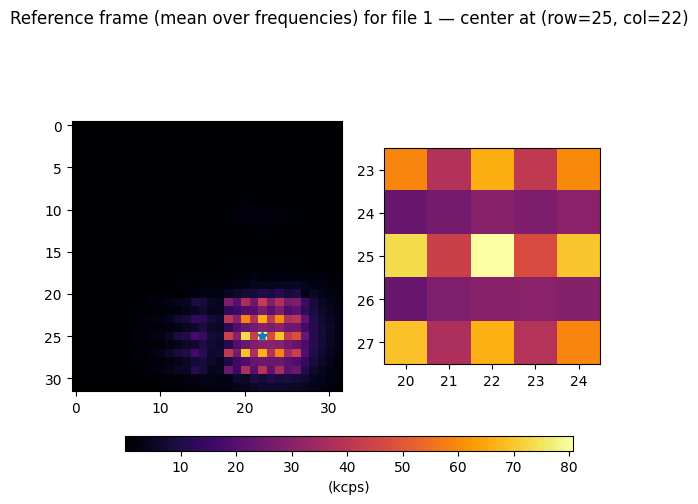

In [26]:
# Use the mean reference frame (averaged over all frequencies) to find the array centre.
n = 5  # size of ROI (n x n pixels)

for k in range(len(n_complete_reps_all)):

    ref_frame = ref_avg_cps_bgsub_all[k,:,:].mean(axis =0)  # (rows, cols) — mean reference over all frequencies
    bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
    #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')
    
    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(1e-3*ref_frame, cmap='inferno')
    plt.plot(bright_rc[1], bright_rc[0], '*', ms=7)

    plt.subplot(1, 2, 2)
    plt.imshow(1e-3*ref_frame, cmap='inferno')
    plt.xlim(bright_rc[1]-int(n/2)-0.5, bright_rc[1]+int(n/2)+0.5)
    plt.ylim(bright_rc[0]+int(n/2)+0.5, bright_rc[0]-int(n/2)-0.5)
    plt.colorbar(label='(kcps)')
    # Replace the per-subplot colorbar with a single shared colorbar (horizontal, bottom)
    fig = plt.gcf()

    # First two axes are the image subplots; any additional axes are the colorbar axes we just created
    ax1, ax2 = fig.axes[0], fig.axes[1]
    for ax_extra in list(fig.axes[2:]):
        ax_extra.remove()

    im1 = ax1.images[-1]
    im2 = ax2.images[-1]
    im2.set_norm(im1.norm)  # ensure both subplots share the same normalization

    # Add a dedicated colorbar axes at the bottom; exclude from tight_layout calculations
    cax = fig.add_axes([0.15, 0.06, 0.70, 0.03])
    cax.set_in_layout(False)

    cbar = fig.colorbar(im1, cax=cax, orientation="horizontal")
    cbar.set_label("(kcps)")
    plt.suptitle(f'Reference frame (mean over frequencies) for file {k+1} — center at (row={bright_rc[0]}, col={bright_rc[1]})')
    plt.tight_layout()

plt.show()

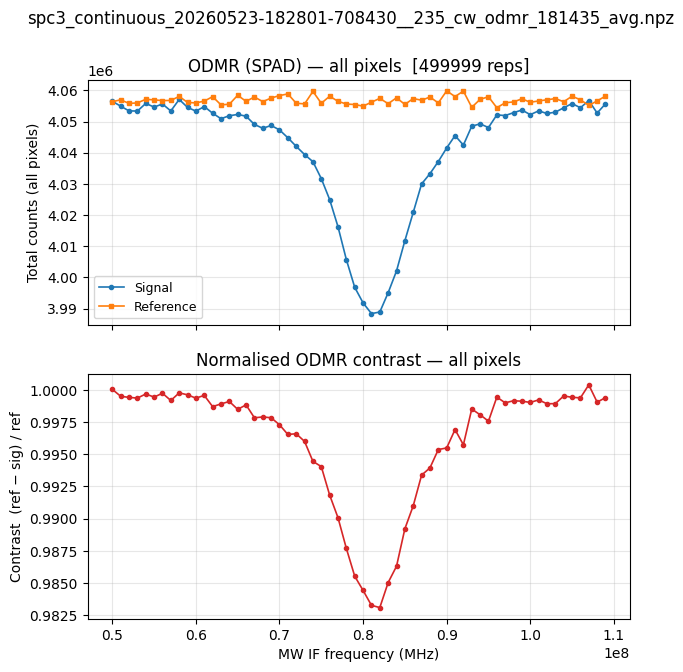

In [27]:
for k in range(len(spad_processed_files)):
    sig_counts  = sig_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)
    ref_counts  = ref_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)

    with np.errstate(divide='ignore', invalid='ignore'):
        contrast_all = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

    fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
    
    plt.suptitle(f'{list(spad_processed_files)[k]}')
    axes[0].plot(f_vec, sig_counts, 'o-', ms=3, lw=1.2, label='Signal')
    axes[0].plot(f_vec, ref_counts, 's-', ms=3, lw=1.2, label='Reference')
    axes[0].set_ylabel('Total counts (all pixels)')
    axes[0].set_title(f'ODMR (SPAD) — all pixels  [{n_complete_reps_all[k]} reps]')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(f_vec, contrast_all, 'o-', ms=3, lw=1.2, color='C3')
    axes[1].set_xlabel('MW IF frequency (MHz)')
    axes[1].set_ylabel('Contrast  (ref − sig) / ref')
    axes[1].set_title('Normalised ODMR contrast — all pixels')
    axes[1].grid(True, alpha=0.3)
    #axes[1].set_ylim([0.96, 1.01])

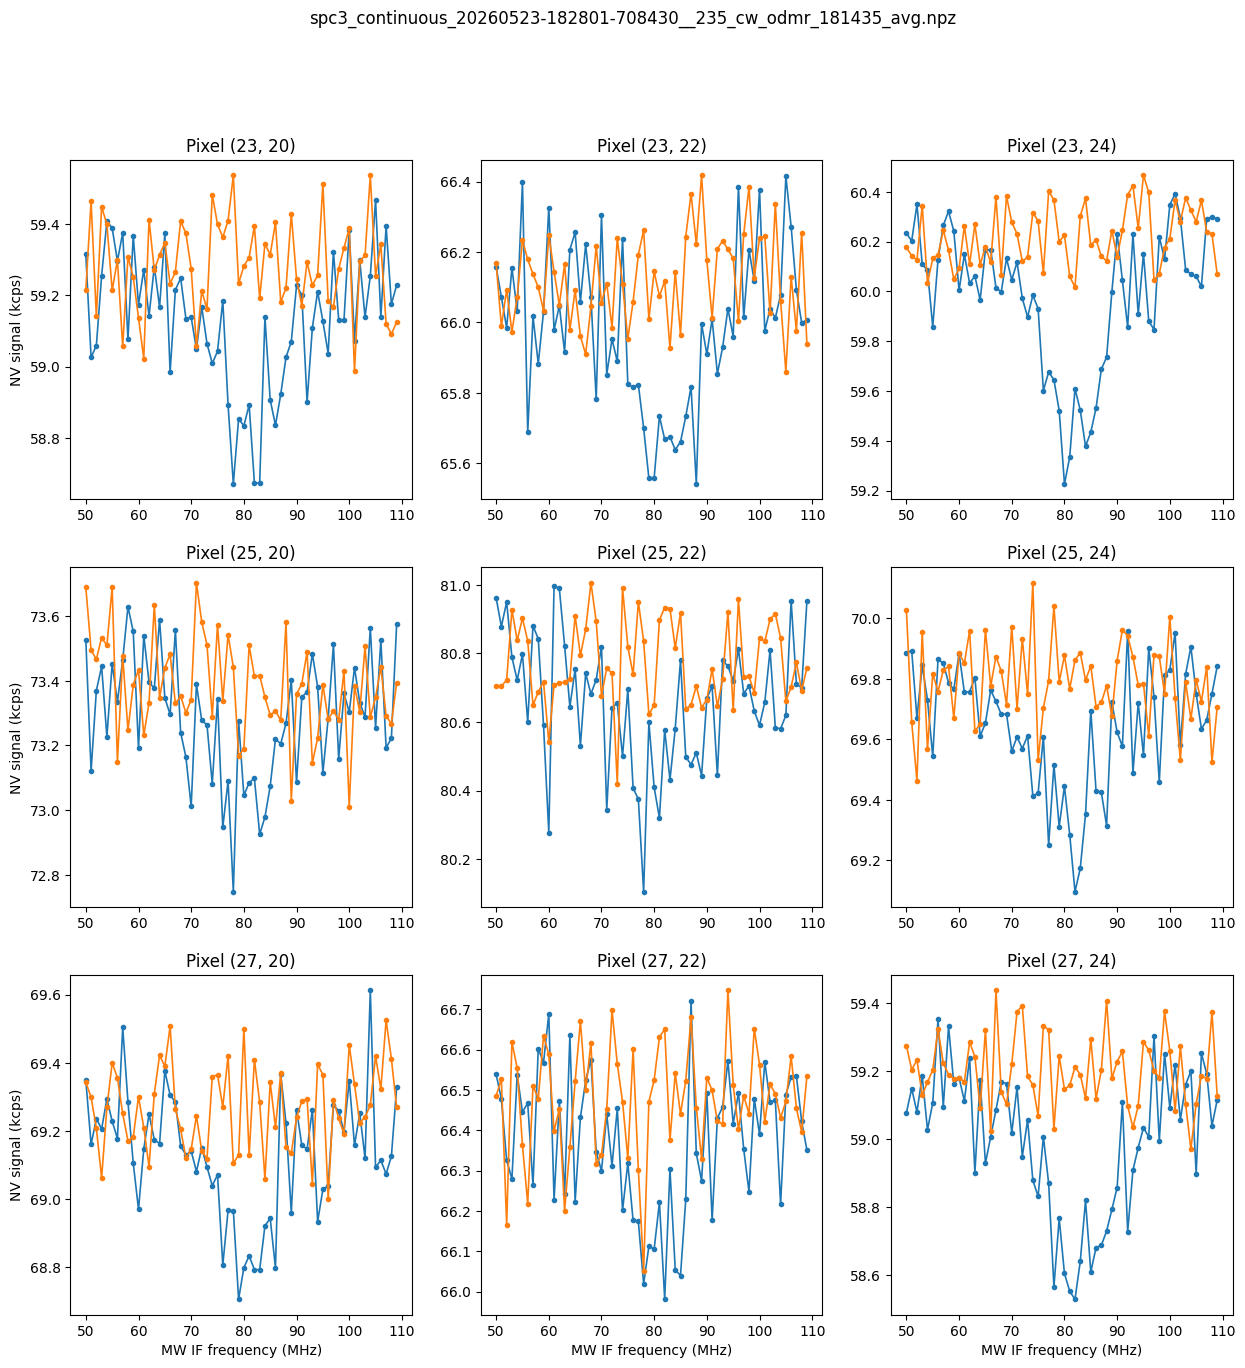

In [28]:
#for each processed file, plot signal and ref for each pixel in 3X3 emitter array centered at brightest pixel
f_mhz = f_vec / 1e6

for k in range(len(spad_processed_files)):

    #find brightest pixel in ref_avg.mean and set as array centre
    ref_frame = ref_avg_cps_bgsub_all[k, :, :, :].mean(axis =0)  # (rows, cols) — mean reference over all frequencies
    bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
    #print(f'Array centre (brightest pixel in ref_avg.mean): row={bright_rc[0]}, col={bright_rc[1]}')

    plt.subplots(3, 3, figsize=(15, 15))

    for i in range(3):
        for j in range(3):

            sig_pix = (sig_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])
            ref_pix = (ref_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2])

            plt.suptitle(f'{list(spad_processed_files)[k]}')
            plt.subplot(3, 3, i*3 + j + 1)
            plt.plot(f_mhz, sig_pix/1000, 'o-', ms=3, lw=1.2, label='Signal')
            plt.plot(f_mhz, ref_pix/1000, 'o-', ms=3, lw=1.2, label='Reference')
            plt.title(f'Pixel ({bright_rc[0]+2*i-2}, {bright_rc[1]+2*j-2})')
            #plt.ylim(0.94,1.02)
            if i==2:
                plt.xlabel('MW IF frequency (MHz)')
            if j==0:
                plt.ylabel('NV signal (kcps)')


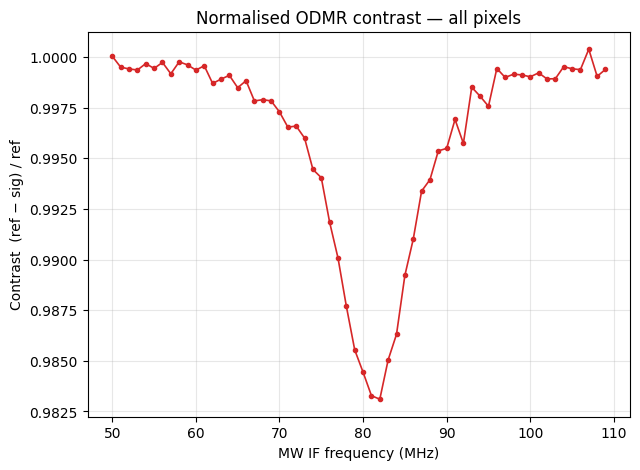

In [29]:
contrast_all = []
#calculate weighted average contrast across all processed files, where weight is number of complete repetitions in each file

for k in range(len(n_complete_reps_all)):
    sig_counts  = sig_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)
    ref_counts  = ref_avg_cps_bgsub_all[k,:,:,:].sum(axis=(-1, -2))   # (F,)

    with np.errstate(divide='ignore', invalid='ignore'):
        contrast = np.where(ref_counts != 0, 1 - (ref_counts - sig_counts) / ref_counts, 0.0)

    contrast_all.append(contrast)

contrast_all = np.array(contrast_all)
contrast_ave = np.average(contrast_all, axis=0, weights=n_complete_reps_all)

plt.figure(figsize=(7, 5))

plt.plot(f_vec/1e6, contrast_ave, 'o-', ms=3, lw=1.2, color='C3')
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('Contrast  (ref − sig) / ref')
plt.title('Normalised ODMR contrast — all pixels')
#plt.ylim([0.97, 1.01])
plt.grid(True, alpha=0.3)

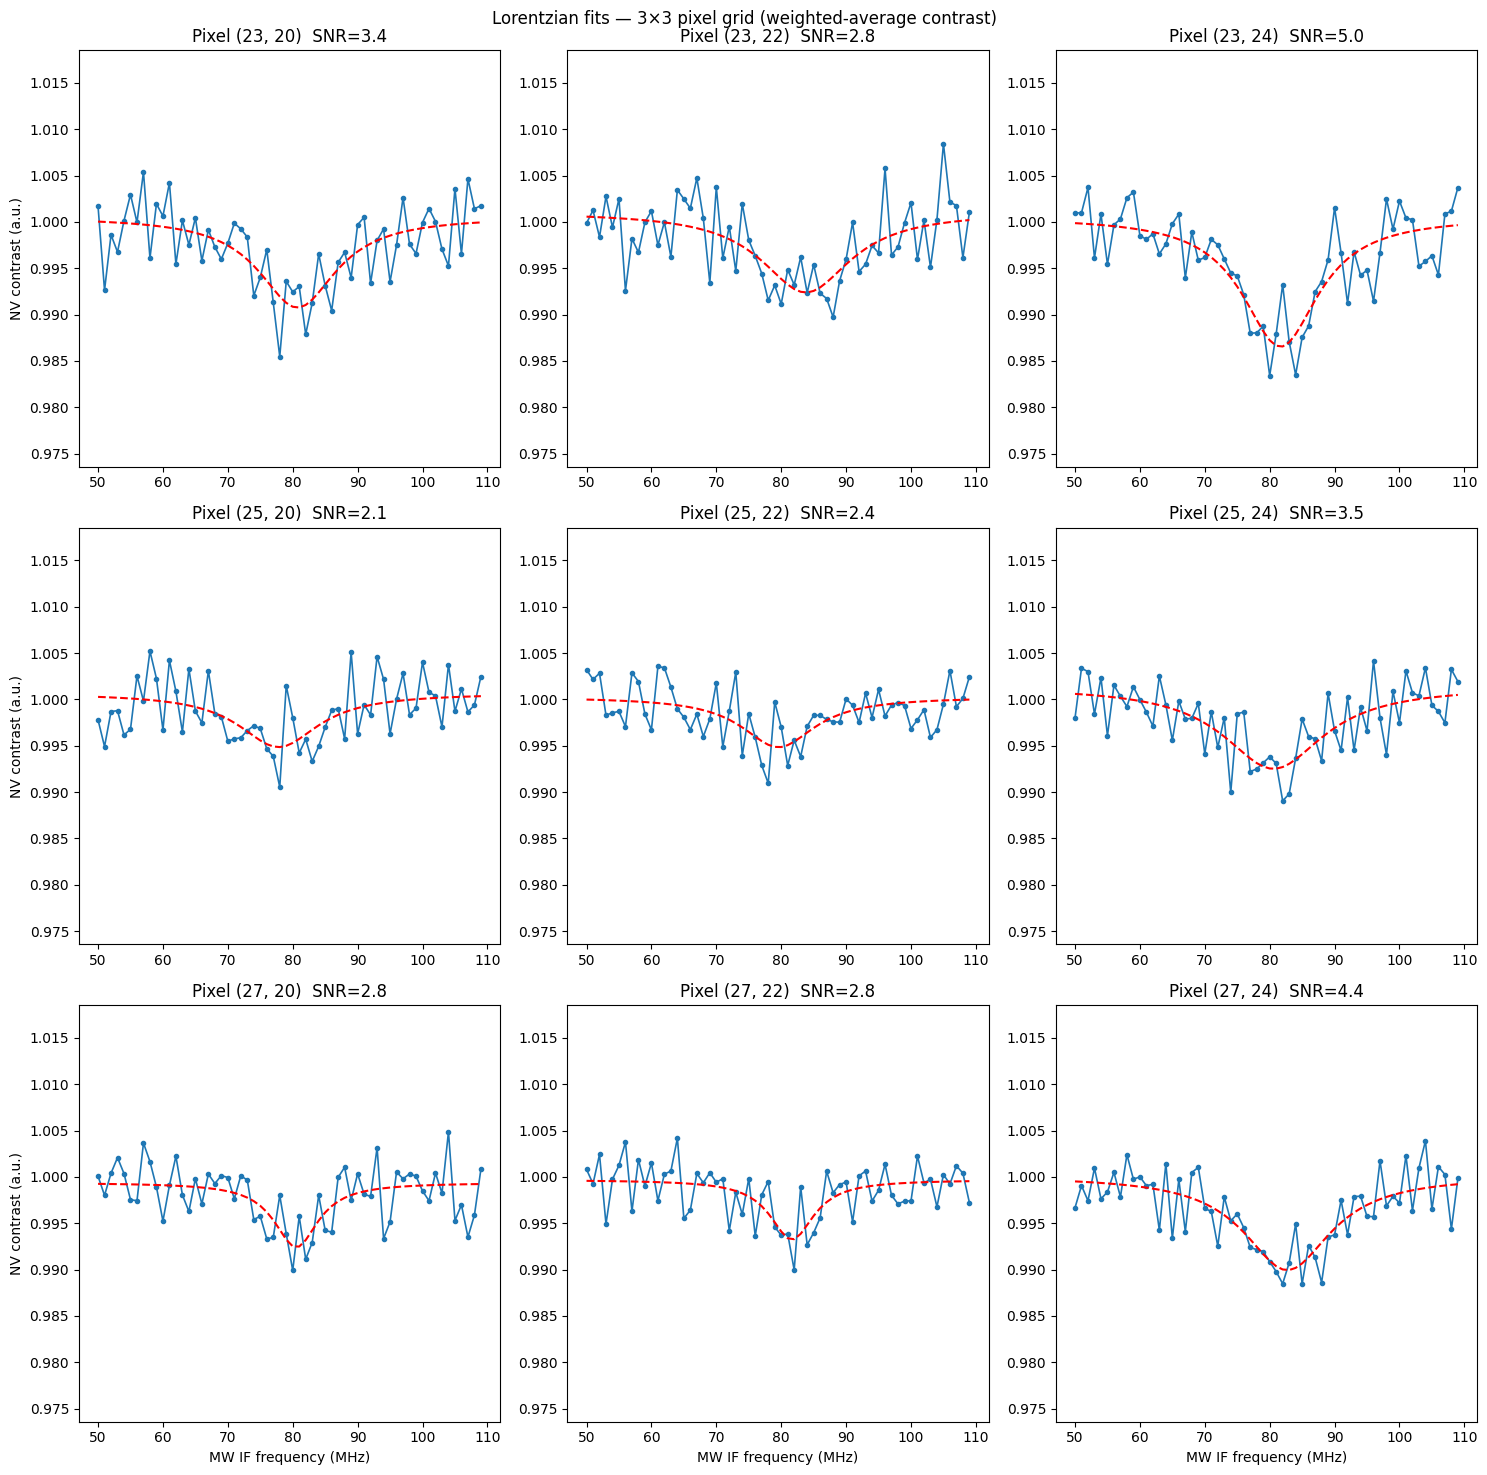


Per-pixel fit results:
  Pixel (23,20):  f0=80.7285 MHz  FWHM=14.597 MHz  amp=-0.009809  SNR=3.4
  Pixel (23,22):  f0=83.8006 MHz  FWHM=16.891 MHz  amp=-0.008695  SNR=2.8
  Pixel (23,24):  f0=81.6497 MHz  FWHM=14.316 MHz  amp=-0.01402  SNR=5.0
  Pixel (25,20):  f0=77.8197 MHz  FWHM=15.023 MHz  amp=-0.005815  SNR=2.1
  Pixel (25,22):  f0=79.5655 MHz  FWHM=13.789 MHz  amp=-0.005422  SNR=2.4
  Pixel (25,24):  f0=80.5980 MHz  FWHM=18.921 MHz  amp=-0.008857  SNR=3.5
  Pixel (27,20):  f0=80.5313 MHz  FWHM=8.252 MHz  amp=-0.006977  SNR=2.8
  Pixel (27,22):  f0=81.6435 MHz  FWHM=8.249 MHz  amp=-0.006454  SNR=2.8
  Pixel (27,24):  f0=82.7168 MHz  FWHM=16.419 MHz  amp=-0.01018  SNR=4.4

Mean SNR: 3.26


In [30]:
#plot weighted average contrast signal for 3X3 grid with fixed center pixel

fitter = Fitter()
f_mhz = f_vec / 1e6

# --- pass 1: compute contrasts and fits for all 9 pixels ---
pixel_data = []
for i in range(3):
    for j in range(3):
        sig_norm_pix_all = []
        for k in range(len(n_complete_reps_all)):
            ref_frame = ref_avg_cps_bgsub_all[k, :, :, :].mean(axis=0)
            bright_rc = np.unravel_index(ref_frame.argmax(), ref_frame.shape)
            sig_pix = sig_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]
            ref_pix = ref_avg_cps_bgsub_all[k, :, bright_rc[0]+2*i-2, bright_rc[1]+2*j-2]
            sig_norm_pix_all.append(1 - ((ref_pix - sig_pix) / ref_pix))

        sig_norm_pix_all = np.array(sig_norm_pix_all)
        sig_norm_pix_avg = np.average(sig_norm_pix_all, axis=0, weights=n_complete_reps_all)
        row, col = bright_rc[0]+2*i-2, bright_rc[1]+2*j-2

        try:
            fit_res = fitter.lorentzian(f_mhz, sig_norm_pix_avg)
            y_fit = fit_res.y_fit
            resid_rms = np.sqrt(np.mean((sig_norm_pix_avg - y_fit) ** 2))
            snr = np.abs(fit_res.params['amp']) / resid_rms if resid_rms > 0 else np.inf
            fit_ok = True
        except Exception:
            fit_res = None
            y_fit = None
            snr = np.nan
            fit_ok = False

        pixel_data.append(dict(row=row, col=col, contrast=sig_norm_pix_avg,
                               fit_res=fit_res, y_fit=y_fit, snr=snr, fit_ok=fit_ok))

# shared y limits across all 9 pixels
all_vals = np.concatenate([d['contrast'] for d in pixel_data])
ylo = 0.99 * all_vals.min()
yhi = 1.01 * all_vals.max()

# --- pass 2: plot ---
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
snr_all = []
fit_results = []

for idx, d in enumerate(pixel_data):
    i, j = idx // 3, idx % 3
    row, col = d['row'], d['col']
    snr_all.append(d['snr'])
    fit_results.append((row, col, d['fit_res'], d['snr']))

    ax = axes[i, j]
    ax.plot(f_mhz, d['contrast'], 'o-', ms=3, lw=1.2, label='Data')
    if d['fit_ok']:
        ax.plot(f_mhz, d['y_fit'], 'r--', lw=1.5,
                label=f"f0={d['fit_res'].params['x0']:.2f} MHz")
    ax.set_title(f"Pixel ({row}, {col})  SNR={d['snr']:.1f}")
    ax.set_ylim(ylo, yhi)
    if i == 2:
        ax.set_xlabel('MW IF frequency (MHz)')
    if j == 0:
        ax.set_ylabel('NV contrast (a.u.)')
    #ax.legend(fontsize=7)

fig.suptitle('Lorentzian fits — 3×3 pixel grid (weighted-average contrast)')
fig.tight_layout()
plt.show()

print("\nPer-pixel fit results:")
for row, col, fit_res, snr in fit_results:
    if fit_res is not None:
        print(f"  Pixel ({row:2d},{col:2d}):  "
              f"f0={fit_res.params['x0']:.4f} MHz  "
              f"FWHM={fit_res.params['fwhm']:.3f} MHz  "
              f"amp={fit_res.params['amp']:.4g}  "
              f"SNR={snr:.1f}")
    else:
        print(f"  Pixel ({row:2d},{col:2d}):  fit failed")
print(f"\nMean SNR: {np.nanmean(snr_all):.2f}")

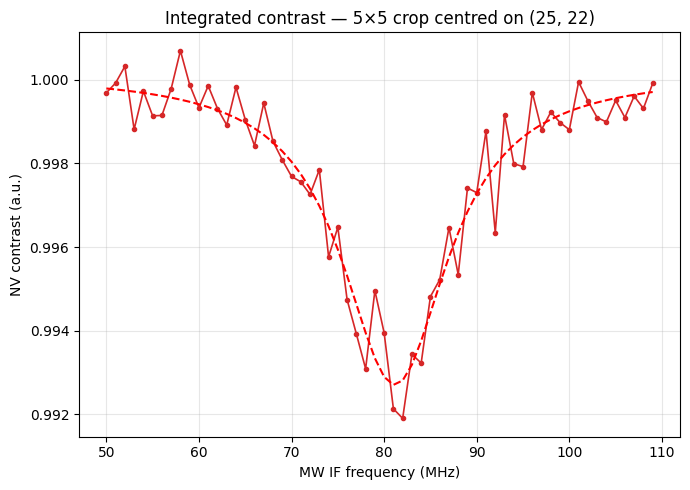

Fit results (5×5 ROI centred on (25, 22)):
  f0:        81.1492 MHz
  FWHM:      14.020 MHz
  amplitude: -0.007444
  SNR (fitted amp/residual RMS):       11.98


In [31]:
# Integrated contrast for 5×5 pixel crop centred on bright_rc

f_mhz = f_vec / 1e6
r0, c0 = bright_rc

contrast_roi_all = []
for k in range(len(n_complete_reps_all)):
    sig_roi = sig_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
    ref_roi = ref_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
    with np.errstate(divide='ignore', invalid='ignore'):
        contrast_roi_all.append(np.where(ref_roi != 0, 1 - (ref_roi - sig_roi) / ref_roi, 0.0))

contrast_roi_avg = np.average(contrast_roi_all, axis=0, weights=n_complete_reps_all)

fit_res_roi = Fitter().lorentzian(f_mhz, contrast_roi_avg)
y_fit_roi = fit_res_roi.y_fit
resid_rms_roi = np.sqrt(np.mean((contrast_roi_avg - y_fit_roi) ** 2))
snr_roi = np.abs(fit_res_roi.params['amp']) / resid_rms_roi if resid_rms_roi > 0 else np.inf

plt.figure(figsize=(7, 5))
plt.plot(f_mhz, contrast_roi_avg, 'o-', ms=3, lw=1.2, color='C3', label='Data')
plt.plot(f_mhz, y_fit_roi, 'r--', lw=1.5, label=f"f0={fit_res_roi.params['x0']:.3f} MHz")
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('NV contrast (a.u.)')
plt.title(f'Integrated contrast — 5×5 crop centred on ({r0}, {c0})')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fit results (5×5 ROI centred on ({r0}, {c0})):")
print(f"  f0:        {fit_res_roi.params['x0']:.4f} MHz")
print(f"  FWHM:      {fit_res_roi.params['fwhm']:.3f} MHz")
print(f"  amplitude: {fit_res_roi.params['amp']:.4g}")
print(f"  SNR (fitted amp/residual RMS):       {snr_roi:.2f}")

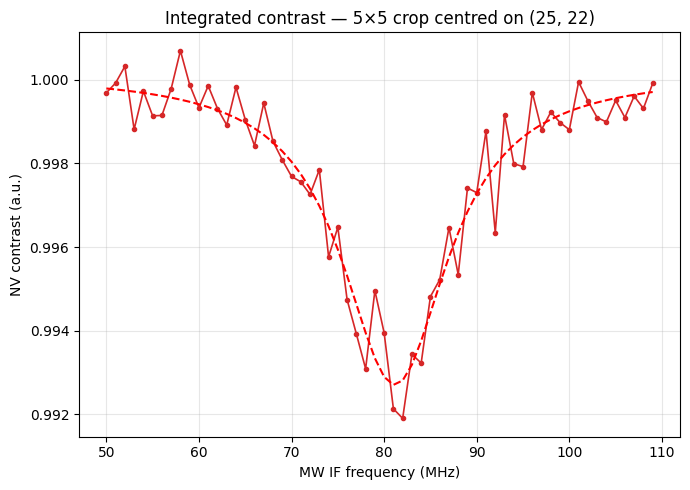

Fit results (5×5 ROI centred on (25, 22)):
  f0:        81.1492 MHz
  FWHM:      14.020 MHz
  amplitude: -0.007444
  SNR (fitted amp/residual RMS):       11.98


In [ ]:
# Integrated contrast for 5×5 pixel crop centred on bright_rc

f_mhz = f_vec / 1e6
r0, c0 = bright_rc

contrast_roi_all = []
for k in range(len(n_complete_reps_all)):
    sig_roi = sig_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
    ref_roi = ref_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
    with np.errstate(divide='ignore', invalid='ignore'):
        contrast_roi_all.append(np.where(ref_roi != 0, 1 - (ref_roi - sig_roi) / ref_roi, 0.0))

contrast_roi_avg = np.average(contrast_roi_all, axis=0, weights=n_complete_reps_all)

fit_res_roi = Fitter().lorentzian(f_mhz, contrast_roi_avg)
y_fit_roi = fit_res_roi.y_fit
resid_rms_roi = np.sqrt(np.mean((contrast_roi_avg - y_fit_roi) ** 2))
snr_roi = np.abs(fit_res_roi.params['amp']) / resid_rms_roi if resid_rms_roi > 0 else np.inf

plt.figure(figsize=(7, 5))
plt.plot(f_mhz, contrast_roi_avg, 'o-', ms=3, lw=1.2, color='C3', label='Data')
plt.plot(f_mhz, y_fit_roi, 'r--', lw=1.5, label=f"f0={fit_res_roi.params['x0']:.3f} MHz")
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('NV contrast (a.u.)')
plt.title(f'Integrated contrast — 5×5 crop centred on ({r0}, {c0})')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fit results (5×5 ROI centred on ({r0}, {c0})):")
print(f"  f0:        {fit_res_roi.params['x0']:.4f} MHz")
print(f"  FWHM:      {fit_res_roi.params['fwhm']:.3f} MHz")
print(f"  amplitude: {fit_res_roi.params['amp']:.4g}")
print(f"  SNR (fitted amp/residual RMS):       {snr_roi:.2f}")

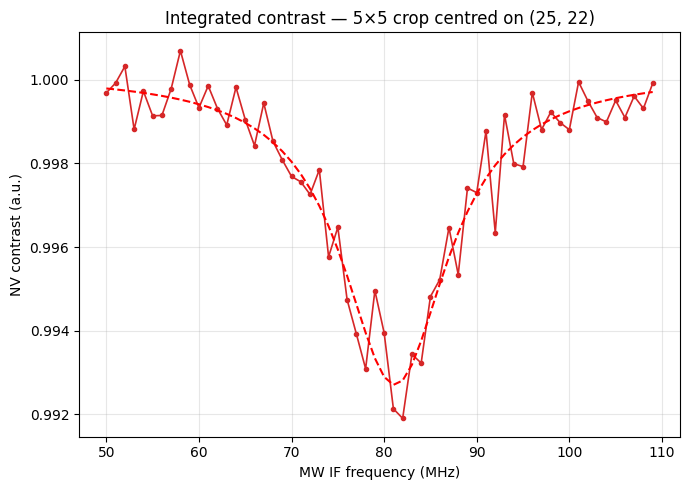

Fit results (5×5 ROI centred on (25, 22)):
  f0:        81.1492 MHz
  FWHM:      14.020 MHz
  amplitude [cps]: -8423
  SNR (using reference measurement):       17.34


In [33]:
#Integrated contrast for 5×5 pixel crop centred on bright_rc
#evaluate noise from mean reference (only works for single file)

f_mhz = f_vec / 1e6
r0, c0 = bright_rc

contrast_roi_all = []
std_all = []
mean_all = []
k = len(n_complete_reps_all)-1 #use last file (should be only one) to evaluate noise from mean reference
sig_roi = sig_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
ref_roi = ref_avg_cps_bgsub_all[k, :, r0-2:r0+3, c0-2:c0+3].sum(axis=(-1, -2))  # (F,)
with np.errstate(divide='ignore', invalid='ignore'):
    contrast_roi_all.append(np.where(ref_roi != 0, 1 - (ref_roi - sig_roi) / ref_roi, 0.0))
mean_all.append(np.mean(ref_roi))
std_all.append(np.std(ref_roi))

contrast_roi_avg = np.average(contrast_roi_all, axis = 0)
std_roi_avg = np.average(std_all, axis=0)
mean_roi_avg = np.average(mean_all, axis=0)
fit_res_roi = Fitter().lorentzian(f_mhz, contrast_roi_avg)
y_fit_roi = fit_res_roi.y_fit
noise = std_roi_avg
amp = fit_res_roi.params['amp']*mean_roi_avg
snr_roi = np.abs(amp) / noise if noise > 0 else np.inf

plt.figure(figsize=(7, 5))
plt.plot(f_mhz, contrast_roi_avg, 'o-', ms=3, lw=1.2, color='C3', label='Data')
plt.plot(f_mhz, y_fit_roi, 'r--', lw=1.5, label=f"f0={fit_res_roi.params['x0']:.3f} MHz")
plt.xlabel('MW IF frequency (MHz)')
plt.ylabel('NV contrast (a.u.)')
plt.title(f'Integrated contrast — 5×5 crop centred on ({r0}, {c0})')
#plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fit results (5×5 ROI centred on ({r0}, {c0})):")
print(f"  f0:        {fit_res_roi.params['x0']:.4f} MHz")
print(f"  FWHM:      {fit_res_roi.params['fwhm']:.3f} MHz")
print(f"  amplitude [cps]: {amp:.4g}")
print(f"  SNR (using reference measurement):       {snr_roi:.2f}")